In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from collections import Counter
from typing import Dict, List, Tuple, Optional
import time
import matplotlib.pyplot as plt
from datasets import load_dataset

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


---
# 1) Data Pipeline

## 1.1 Loading and Tokenizing IMDb

We use the IMDb sentiment classification dataset (25k train, 25k test). Each review is labeled as positive (1) or negative (0). We subsample for speed.

**Key practical concern**: Reviews have variable lengths (from a few words to thousands). We must handle this efficiently with padding and packing.

In [2]:
# Load IMDb dataset from HuggingFace
raw_dataset = load_dataset("imdb")
print(f"Train size: {len(raw_dataset['train'])}, Test size: {len(raw_dataset['test'])}")
print(f"Example: {raw_dataset['train'][0]['text'][:200]}...")
print(f"Label: {raw_dataset['train'][0]['label']}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train size: 25000, Test size: 25000
Example: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev...
Label: 0


In [3]:
# Simple whitespace + lowercasing tokenizer
# In production, use a proper tokenizer (spaCy, sentencepiece, etc.)
import re

def tokenize(text: str) -> List[str]:
    """Lowercase, strip HTML, split on non-alphanumeric."""
    text = re.sub(r"<[^>]+>", " ", text)  # Remove HTML tags
    text = text.lower()
    return re.findall(r"\b\w+\b", text)

## 1.2 Building Vocabulary

We build a vocabulary from the training set only (never peek at test data). Two special tokens:
- `<pad>` (index 0): used to fill shorter sequences in a batch
- `<unk>` (index 1): used for out-of-vocabulary words at test time

In [4]:
class Vocabulary:
    """Maps tokens to integer indices with special tokens."""

    PAD_TOKEN = "<pad>"
    UNK_TOKEN = "<unk>"

    def __init__(self, max_vocab_size: int = 25000, min_freq: int = 2):
        self.max_vocab_size = max_vocab_size
        self.min_freq = min_freq
        self.token_to_idx: Dict[str, int] = {}
        self.idx_to_token: Dict[int, str] = {}

    def build(self, tokenized_texts: List[List[str]]) -> "Vocabulary":
        """Build vocabulary from tokenized training texts."""
        counter = Counter(tok for text in tokenized_texts for tok in text)

        # Reserve indices 0 and 1 for special tokens
        self.token_to_idx = {self.PAD_TOKEN: 0, self.UNK_TOKEN: 1}

        # Add most common tokens (above min_freq) up to max_vocab_size
        for token, freq in counter.most_common(self.max_vocab_size - 2):
            if freq < self.min_freq:
                break
            self.token_to_idx[token] = len(self.token_to_idx)

        self.idx_to_token = {i: t for t, i in self.token_to_idx.items()}
        return self

    def encode(self, tokens: List[str]) -> List[int]:
        """Convert token list to index list."""
        unk_idx = self.token_to_idx[self.UNK_TOKEN]
        return [self.token_to_idx.get(t, unk_idx) for t in tokens]

    def __len__(self) -> int:
        return len(self.token_to_idx)


# Tokenize all training texts
train_tokens = [tokenize(ex["text"]) for ex in raw_dataset["train"]]

# Build vocabulary from training data only
vocab = Vocabulary(max_vocab_size=25000, min_freq=2).build(train_tokens)
print(f"Vocabulary size: {len(vocab)}")
print(f"Example encoding: {vocab.encode(['this', 'movie', 'is', 'great'])}")

Vocabulary size: 25000
Example encoding: [11, 18, 7, 85]


## 1.3 Dataset and DataLoader with Padding

### Why padding and packing matters

In a batch, sequences have different lengths. We must:
1. **Pad** shorter sequences with zeros so they fit in a single tensor
2. **Pack** the padded tensor using `pack_padded_sequence` so the LSTM skips pad tokens

Without packing, the LSTM processes pad tokens as real inputs, which wastes computation and corrupts the hidden state.

**Sample I/O for padding:**
```
Before:  [[5, 3, 8], [2, 7]]          # variable-length
After:   [[5, 3, 8], [2, 7, 0]]        # padded, lengths = [3, 2]
```

In [5]:
class IMDbDataset(Dataset):
    """Encodes text as integer sequences, truncates to max_len."""

    def __init__(
        self,
        hf_split,
        vocab: Vocabulary,
        max_len: int = 300,
    ):
        self.labels = []
        self.encoded = []

        for example in hf_split:
            tokens = tokenize(example["text"])[:max_len]
            self.encoded.append(torch.tensor(vocab.encode(tokens), dtype=torch.long))
            self.labels.append(example["label"])

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int, int]:
        """Returns (encoded_text, label, length)."""
        return self.encoded[idx], self.labels[idx], len(self.encoded[idx])


def collate_fn(
    batch: List[Tuple[torch.Tensor, int, int]],
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Custom collate function for variable-length sequences.

    1. Sort by length (descending) — required by pack_padded_sequence
    2. Pad all sequences to the length of the longest in this batch
    3. Return (padded_texts, labels, lengths)
    """
    # Sort batch by sequence length, descending
    batch.sort(key=lambda x: x[2], reverse=True)
    texts, labels, lengths = zip(*batch)

    # Pad sequences: each is (seq_len_i,) → all become (max_seq_len_in_batch,)
    # (batch_num, max_seq_len)
    padded = pad_sequence(texts, batch_first=True, padding_value=0)

    return padded, torch.tensor(labels, dtype=torch.long), torch.tensor(lengths)


# Create datasets
MAX_LEN = 300
BATCH_SIZE = 64

train_dataset = IMDbDataset(raw_dataset["train"], vocab, max_len=MAX_LEN)
test_dataset = IMDbDataset(raw_dataset["test"], vocab, max_len=MAX_LEN)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
)

# Inspect one batch
texts_batch, labels_batch, lengths_batch = next(iter(train_loader))
print(f"Batch text shape:    {texts_batch.shape}  # (batch_num, max_seq_len)")
print(f"Batch labels shape:  {labels_batch.shape}  # (batch_num,)")
print(f"Batch lengths:       {lengths_batch[:10].tolist()} (first 10, sorted desc)")

Batch text shape:    torch.Size([64, 300])  # (batch_num, max_seq_len)
Batch labels shape:  torch.Size([64])  # (batch_num,)
Batch lengths:       [300, 300, 300, 300, 300, 300, 300, 300, 300, 300] (first 10, sorted desc)


---
# 2) Pretrained Embeddings (GloVe)

## 2.1 Motivation

Word embeddings map discrete tokens to dense vectors where semantically similar words are nearby. **Pretrained embeddings** (trained on massive corpora like Wikipedia) give our model a head start — especially valuable when labeled data is limited.

**GloVe** (Global Vectors) learns embeddings by factorizing the word co-occurrence matrix. The 6B variant has 400k words with 50/100/200/300-dimensional vectors.

In [6]:
import urllib.request
import zipfile
import os

GLOVE_DIM = 100
GLOVE_PATH = f"glove.6B.{GLOVE_DIM}d.txt"

# Download GloVe if not present
if not os.path.exists(GLOVE_PATH):
    print("Downloading GloVe embeddings...")
    urllib.request.urlretrieve(
        "https://nlp.stanford.edu/data/glove.6B.zip", "glove.6B.zip"
    )
    with zipfile.ZipFile("glove.6B.zip", "r") as z:
        z.extract(GLOVE_PATH)
    os.remove("glove.6B.zip")
    print("Done.")
else:
    print(f"{GLOVE_PATH} already exists.")

Done.


In [7]:
def load_glove_vectors(path: str) -> Dict[str, np.ndarray]:
    """Load GloVe vectors into a word→vector dictionary."""
    vectors = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vec = np.array(parts[1:], dtype=np.float32)
            vectors[word] = vec
    return vectors


glove_vectors = load_glove_vectors(GLOVE_PATH)
print(f"Loaded {len(glove_vectors)} GloVe vectors of dimension {GLOVE_DIM}")
print(f"Example — 'movie': {glove_vectors['movie'][:5]}...")

Loaded 400000 GloVe vectors of dimension 100
Example — 'movie': [ 0.38251  0.14821  0.60601 -0.51533  0.43992]...


In [8]:
def build_embedding_matrix(
    vocab: Vocabulary,
    glove_vectors: Dict[str, np.ndarray],
    embed_dim: int,
) -> torch.Tensor:
    """
    Create embedding matrix aligned with our vocabulary.

    Words found in GloVe get their pretrained vector.
    Words not found get random initialization (scaled like GloVe).
    <pad> stays as zeros.

    Returns: (vocab_size, embed_dim)
    """
    vocab_size = len(vocab)
    # (vocab_size, embed_dim)
    matrix = np.zeros((vocab_size, embed_dim), dtype=np.float32)

    # GloVe vectors have std ≈ 0.38; use that for random init
    found, total = 0, 0

    for token, idx in vocab.token_to_idx.items():
        if token in (vocab.PAD_TOKEN,):
            continue  # Keep <pad> as zeros
        total += 1
        if token in glove_vectors:
            matrix[idx] = glove_vectors[token]
            found += 1
        else:
            # Random init for OOV words
            matrix[idx] = np.random.normal(scale=0.38, size=embed_dim)

    print(f"GloVe coverage: {found}/{total} ({100*found/total:.1f}%) vocabulary tokens")
    return torch.tensor(matrix)


embedding_matrix = build_embedding_matrix(vocab, glove_vectors, GLOVE_DIM)
print(f"Embedding matrix shape: {embedding_matrix.shape}  # (vocab_size, embed_dim)")

GloVe coverage: 24700/24999 (98.8%) vocabulary tokens
Embedding matrix shape: torch.Size([25000, 100])  # (vocab_size, embed_dim)


---
# 3) LSTM Sentiment Classifier

## 3.1 Architecture

```
token indices → Embedding → pack_padded_sequence → LSTM → extract last hidden → Dropout → Linear → logits
```

**Critical detail**: We must extract the hidden state at the **actual** last timestep for each sequence (not the padded end). With packed sequences, `h_n` from `nn.LSTM` already gives us this correctly.

**Design choices**:
- `pack_padded_sequence` / `pad_packed_sequence`: tells the LSTM to skip padding tokens
- Dropout between LSTM output and classifier: regularization
- `bidirectional=True` variant: processes sequence forward AND backward, concatenates final hidden states


## Why `pack_padded_sequence` Matters

Without packing, the LSTM processes `<pad>` tokens as real inputs. This has two problems:
1. **Wasted computation**: Processing zeros through gates and tanh is pointless
2. **Corrupted hidden state**: The LSTM's final hidden state `h_n` would reflect the pad positions, not the actual last word. This is subtle but critical — extracting `h_n` from an unpadded LSTM gives wrong results for shorter sequences in the batch.

With packing, PyTorch internally sorts and batches only the valid timesteps, then returns `h_n` at each sequence's true final position.

In [9]:
class RecurrentClassifier(nn.Module):
    """
    Flexible recurrent classifier supporting RNN, GRU, and LSTM,
    with optional bidirectionality and pretrained embeddings.
    """

    CELL_TYPES = {"rnn": nn.RNN, "gru": nn.GRU, "lstm": nn.LSTM}

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        num_classes: int,
        num_layers: int = 1,
        cell_type: str = "lstm",
        bidirectional: bool = False,
        dropout: float = 0.3,
        pretrained_embeddings: Optional[torch.Tensor] = None,
        freeze_embeddings: bool = True,
        pad_idx: int = 0,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.cell_type = cell_type

        # Embedding layer: padding_idx=0 ensures <pad> always maps to zeros
        # (batch_num, seq_len) → (batch_num, seq_len, embed_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(pretrained_embeddings)
            if freeze_embeddings:
                self.embedding.weight.requires_grad = False

        # Recurrent layer
        # (batch_num, seq_len, embed_dim) → (batch_num, seq_len, hidden_dim * num_directions)
        rnn_cls = self.CELL_TYPES[cell_type]
        self.rnn = rnn_cls(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # The classifier input dimension depends on bidirectionality
        num_directions = 2 if bidirectional else 1
        classifier_input_dim = hidden_dim * num_directions

        self.dropout = nn.Dropout(dropout)

        # (batch_num, hidden_dim * num_directions) → (batch_num, num_classes)
        self.fc = nn.Linear(classifier_input_dim, num_classes)

    def forward(
        self,
        text: torch.Tensor,
        lengths: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            text: (batch_num, max_seq_len) padded integer indices
            lengths: (batch_num,) actual lengths before padding
        Returns:
            logits: (batch_num, num_classes)
        """
        # Embed tokens
        # (batch_num, max_seq_len) → (batch_num, max_seq_len, embed_dim)
        embedded = self.embedding(text)

        # Pack padded sequences so LSTM skips padding positions
        # This is crucial for correct hidden state computation
        packed = pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=True
        )

        # Run through recurrent layer
        # packed_output contains all hidden states; h_n is the final hidden state
        if self.cell_type == "lstm":
            packed_output, (h_n, c_n) = self.rnn(packed)
        else:
            packed_output, h_n = self.rnn(packed)

        # h_n shape: (num_layers * num_directions, batch_num, hidden_dim)
        # We want the final layer's hidden state(s)
        if self.bidirectional:
            # Concatenate forward and backward final hidden states
            # Forward: h_n[-2] — last layer, forward direction
            # Backward: h_n[-1] — last layer, backward direction
            # (batch_num, hidden_dim * 2)
            hidden = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            # (batch_num, hidden_dim)
            hidden = h_n[-1]

        # Classify
        # (batch_num, hidden_dim * num_directions) → (batch_num, num_classes)
        logits = self.fc(self.dropout(hidden))

        return logits

## 3.2 Training

In [10]:
def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    clip_norm: float = 5.0,
) -> Tuple[float, float]:
    """Train for one epoch, return (avg_loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for texts, labels, lengths in loader:
        texts, labels = texts.to(device), labels.to(device)

        # (batch_num, num_classes)
        logits = model(texts, lengths)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping: essential for RNN stability
        nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
) -> Tuple[float, float]:
    """Evaluate model, return (avg_loss, accuracy)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for texts, labels, lengths in loader:
        texts, labels = texts.to(device), labels.to(device)

        logits = model(texts, lengths)
        loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def run_experiment(
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    num_epochs: int = 5,
    lr: float = 1e-3,
) -> Dict[str, List[float]]:
    """Full training loop with logging."""
    model = model.to(device)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    start = time.time()

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        test_loss, test_acc = evaluate(model, test_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        elapsed = time.time() - start
        print(
            f"Epoch {epoch}/{num_epochs} ({elapsed:.0f}s) | "
            f"Train: loss={train_loss:.4f} acc={train_acc:.4f} | "
            f"Test: loss={test_loss:.4f} acc={test_acc:.4f}"
        )

    return history

**Bidirectional LSTM**
A unidirectional LSTM can only use **past context** (left-to-right). For classification, we want the model to understand the full sentence, so we also process it **right-to-left**. The bidirectional LSTM concatenates both directions' final hidden states:

$$h_{\text{final}} = [\overrightarrow{h_T} ; \overleftarrow{h_1}]$$

This doubles the representation size but gives the classifier access to both left and right context.

**When NOT to use bidirectional**: In autoregressive tasks (text generation, language modeling) where you can't see the future at inference time.

---
# 5) Comparison

In [11]:
HIDDEN_DIM = 128
NUM_CLASSES = 2
NUM_EPOCHS = 5

configs = {
    "Vanilla RNN": {"cell_type": "rnn", "bidirectional": False},
    "GRU": {"cell_type": "gru", "bidirectional": False},
    "LSTM": {"cell_type": "lstm", "bidirectional": False},
    "BiLSTM": {"cell_type": "lstm", "bidirectional": True},
}

all_histories = {}

for name, cfg in configs.items():
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")

    model = RecurrentClassifier(
        vocab_size=len(vocab),
        embed_dim=GLOVE_DIM,
        hidden_dim=HIDDEN_DIM,
        num_classes=NUM_CLASSES,
        num_layers=1,
        dropout=0.3,
        pretrained_embeddings=embedding_matrix,
        freeze_embeddings=True,
        **cfg,
    )

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {n_params:,}")

    history = run_experiment(model, train_loader, test_loader, num_epochs=NUM_EPOCHS)
    all_histories[name] = history


Training: Vanilla RNN
Trainable parameters: 29,698
Epoch 1/5 (8s) | Train: loss=0.6756 acc=0.5796 | Test: loss=0.6566 acc=0.6136
Epoch 2/5 (15s) | Train: loss=0.6338 acc=0.6480 | Test: loss=0.6138 acc=0.6752
Epoch 3/5 (22s) | Train: loss=0.6280 acc=0.6546 | Test: loss=0.7026 acc=0.5298
Epoch 4/5 (29s) | Train: loss=0.6298 acc=0.6522 | Test: loss=0.6160 acc=0.6689
Epoch 5/5 (36s) | Train: loss=0.6091 acc=0.6835 | Test: loss=0.6623 acc=0.5976

Training: GRU
Trainable parameters: 88,578
Epoch 1/5 (7s) | Train: loss=0.4977 acc=0.7444 | Test: loss=0.3660 acc=0.8416
Epoch 2/5 (14s) | Train: loss=0.3452 acc=0.8540 | Test: loss=0.3260 acc=0.8579
Epoch 3/5 (21s) | Train: loss=0.3133 acc=0.8695 | Test: loss=0.3036 acc=0.8707
Epoch 4/5 (29s) | Train: loss=0.2851 acc=0.8817 | Test: loss=0.2914 acc=0.8753
Epoch 5/5 (36s) | Train: loss=0.2669 acc=0.8886 | Test: loss=0.2862 acc=0.8792

Training: LSTM
Trainable parameters: 118,018
Epoch 1/5 (7s) | Train: loss=0.6199 acc=0.6563 | Test: loss=0.5617 acc

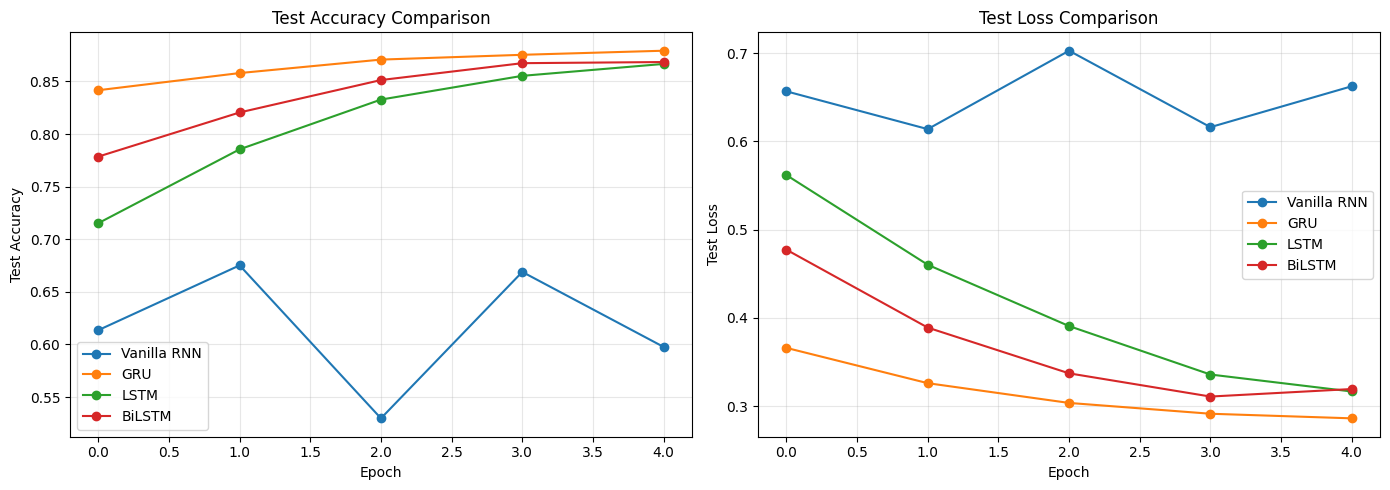


Final Test Accuracy:
-----------------------------------
  Vanilla RNN    : 0.5976
  GRU            : 0.8792
  LSTM           : 0.8666
  BiLSTM         : 0.8684


In [12]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, history in all_histories.items():
    axes[0].plot(history["test_acc"], label=name, marker="o")
    axes[1].plot(history["test_loss"], label=name, marker="o")

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Test Accuracy")
axes[0].set_title("Test Accuracy Comparison")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Test Loss")
axes[1].set_title("Test Loss Comparison")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\nFinal Test Accuracy:")
print("-" * 35)
for name, history in all_histories.items():
    print(f"  {name:<15}: {history['test_acc'][-1]:.4f}")

---
# Summary

**Practical lessons from this notebook:**

1. **`pack_padded_sequence` is not optional** — without it, the LSTM's `h_n` for shorter sequences in a batch is computed at the wrong position (after padding, not after the actual last token)

2. **Pretrained embeddings (GloVe) provide a strong baseline** — they encode semantic relationships learned from billions of words, which is especially valuable for limited labeled data

3. **BiLSTM consistently outperforms unidirectional** for classification because it captures both left and right context (but cannot be used for autoregressive generation)

4. **GRU is a competitive alternative to LSTM** — fewer parameters, similar performance, faster training. Prefer GRU when data is limited or latency matters

5. **Gradient clipping** (`clip_grad_norm_`) is essential for any recurrent architecture — set it between 1.0 and 10.0

**Limitations of RNNs** (addressed in Notebook 3):
- Sequential processing prevents parallelization → slow training
- Even LSTM/GRU struggle with very long sequences (>500 tokens)